# Decision Tree Diabetes

## - Carga y filtrado de datos (sin Insulin ni SkinThickness)

In [117]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [118]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/diabetes.csv')

df.drop(['Insulin', 'SkinThickness'], axis=1, inplace=True)

indices_a_eliminar = df[(df['Glucose'] == 0) | (df['BMI'] == 0) | (df['BloodPressure'] == 0)].index
df.drop(indices_a_eliminar, inplace=True)
df = df.reset_index(drop=True)
df

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,33.6,0.627,50,1
1,1,85,66,26.6,0.351,31,0
2,8,183,64,23.3,0.672,32,1
3,1,89,66,28.1,0.167,21,0
4,0,137,40,43.1,2.288,33,1
...,...,...,...,...,...,...,...
719,10,101,76,32.9,0.171,63,0
720,2,122,70,36.8,0.340,27,0
721,5,121,72,26.2,0.245,30,0
722,1,126,60,30.1,0.349,47,1


## - División de la muestra y árbol de decisión

In [119]:
x = df[['Pregnancies', 'Glucose', 'BloodPressure',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [120]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [121]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Crear el objeto del modelo
# Usamos random_state para que los resultados sean siempre iguales
clf = DecisionTreeClassifier(max_depth=4, random_state=42) 

# 2. Entrenar con los datos de entrenamiento
clf.fit(x_train, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred = clf.predict(x_test)

In [122]:
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión (Accuracy): 0.81

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86       102
           1       0.65      0.79      0.72        43

    accuracy                           0.81       145
   macro avg       0.78      0.81      0.79       145
weighted avg       0.83      0.81      0.82       145



La variable objetivo en la Clase 1 que nos interesa más tiene una precisión baja aún por lo que es necesario mejorar el modelo.

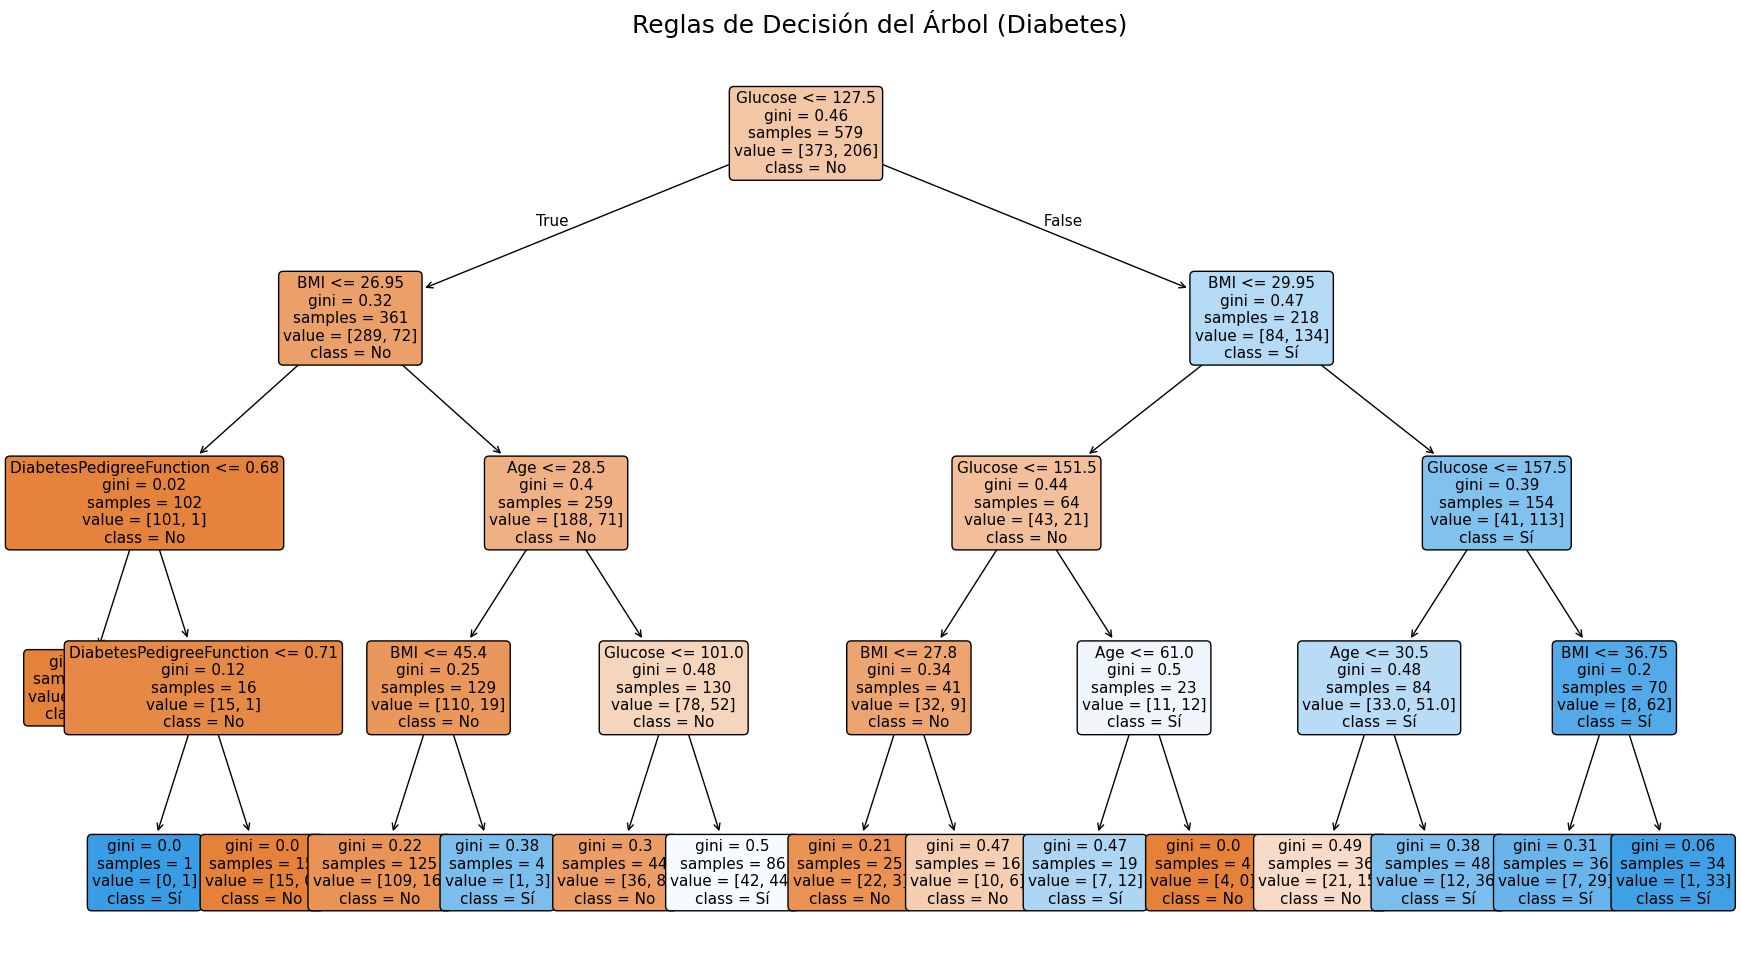

In [123]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 12))

plot_tree(
    clf, 
    feature_names=x.columns, 
    class_names=['No', 'Sí'], 
    filled=True, 
    rounded=True,
    fontsize=11,
    precision=2       # Limita los decimales para que el texto sea más corto
)

plt.title("Reglas de Decisión del Árbol (Diabetes)", fontsize=18)
plt.show()

## - Entrenamiento y optimización

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# 1. Definimos el "espacio" de búsqueda (qué queremos probar)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', None]
}

# 2. Configuramos el Grid Search con Validación Cruzada (cv=5)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='accuracy'
)

# 3. Entrenamos buscando la mejor combinación
grid_search.fit(x_train, y_train)

# 4. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Mejor precisión en entrenamiento (CV): {grid_search.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 20}
Mejor precisión en entrenamiento (CV): 0.7444


In [125]:
# Usamos el mejor modelo encontrado automáticamente
best_clf = grid_search.best_estimator_
y_pred_opt = best_clf.predict(x_test)

print("\nResultado Final en el Set de Prueba:")
print(f"Precisión Optimizada: {accuracy_score(y_test, y_pred_opt):.4f}")


Resultado Final en el Set de Prueba:
Precisión Optimizada: 0.7448


<Figure size 800x600 with 0 Axes>

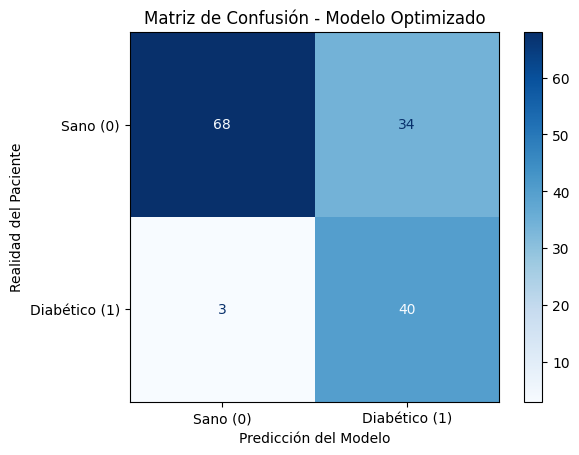

In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz con los resultados de tu modelo optimizado
cm = confusion_matrix(y_test, y_pred_opt)

# 2. La graficamos de forma elegante
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Diabético (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusión - Modelo Optimizado')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Paciente')
plt.show()

In [127]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Creamos el modelo usando tus mejores hiperparámetros encontrados
# pero añadiendo el balanceo de clases
clf_balanced = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5, 
    min_samples_leaf=5, 
    min_samples_split=20,
    class_weight='balanced',  # <--- El cambio clave
    random_state=42
)

# 2. Entrenamos y predecimos
clf_balanced.fit(x_train, y_train)
y_pred_balanced = clf_balanced.predict(x_test)

# 3. Mostramos el nuevo informe
print("--- Informe de Clasificación (Modelo Balanceado) ---")
print(classification_report(y_test, y_pred_balanced))

# 4. Comparamos con la matriz de confusión anterior
print("\nNueva Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_balanced))

--- Informe de Clasificación (Modelo Balanceado) ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       102
           1       0.72      0.72      0.72        43

    accuracy                           0.83       145
   macro avg       0.80      0.80      0.80       145
weighted avg       0.83      0.83      0.83       145


Nueva Matriz de Confusión:
[[90 12]
 [12 31]]


## Análisis de los resultados:
Luego de realizar este primer modelo se volvió a correr, pero con la base de datos sin las filas de datos 0 de Insulin y SkinThickness.

### El primer modelo (Eliminando Insulin y Skinthickness):
Accuracy: 0.83 (Alto).

Balance: Al usar class_weight='balanced' se logra que la precisión y el recall de la clase 1 (diabéticos) suba a 0.72. Es un modelo muy equilibrado y útil.

Funciona porque al conservar más filas, el árbol tiene suficientes ejemplos para entender los patrones, a pesar de haber eliminado solo Insulin y SkinThickness.

### El segundo modelo (Eliminando todas las filas con ceros):
Accuracy: Cae a 0.73.

El problema es que el support (la cantidad de datos) pasa de tener 145 casos de prueba a solo 79. Al borrar tantas filas, el modelo sufre de "hambre de datos" y pierde capacidad de generalizar, especialmente para detectar a los diabéticos (Recall de 0.59).

# Prueba con df entero con Insulin y SkinThickness (pero sacrificando la mitad de datos)

## - Carga y filtrado de datos (con Insulin y SkinThickness)

In [128]:
df = pd.read_csv('/workspaces/IgnacioSabinoG-IntroML/data/raw/diabetes.csv')

indices_a_eliminar = df[(df['Glucose'] == 0) | (df['BMI'] == 0) | (df['BloodPressure'] == 0) | (df['Insulin'] == 0) | (df['SkinThickness'] == 0)].index
df.drop(indices_a_eliminar, inplace=True)
df = df.reset_index(drop=True)

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,89,66,23,94,28.1,0.167,21,0
1,0,137,40,35,168,43.1,2.288,33,1
2,3,78,50,32,88,31.0,0.248,26,1
3,2,197,70,45,543,30.5,0.158,53,1
4,1,189,60,23,846,30.1,0.398,59,1
...,...,...,...,...,...,...,...,...,...
387,0,181,88,44,510,43.3,0.222,26,1
388,1,128,88,39,110,36.5,1.057,37,1
389,2,88,58,26,16,28.4,0.766,22,0
390,10,101,76,48,180,32.9,0.171,63,0


## - División de la muestra y árbol

In [129]:
x = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

In [130]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Crear el objeto del modelo
# Usamos random_state para que los resultados sean siempre iguales
clf = DecisionTreeClassifier(max_depth=4, random_state=42) 

# 2. Entrenar con los datos de entrenamiento
clf.fit(x_train, y_train)

# 3. Realizar predicciones sobre el set de prueba
y_pred = clf.predict(x_test)

In [132]:
print(f"Precisión (Accuracy): {accuracy_score(y_test, y_pred):.2f}")
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

Precisión (Accuracy): 0.73

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        52
           1       0.67      0.44      0.53        27

    accuracy                           0.73        79
   macro avg       0.71      0.66      0.67        79
weighted avg       0.72      0.73      0.72        79



## - Entrenamiento y optimización

In [133]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# 1. Definimos el "espacio" de búsqueda (qué queremos probar)
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'class_weight': ['balanced', None]
}

# 2. Configuramos el Grid Search con Validación Cruzada (cv=5)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    scoring='accuracy'
)

# 3. Entrenamos buscando la mejor combinación
grid_search.fit(x_train, y_train)

# 4. Resultados
print("Mejores hiperparámetros encontrados:", grid_search.best_params_)
print(f"Mejor precisión en entrenamiento (CV): {grid_search.best_score_:.4f}")

Mejores hiperparámetros encontrados: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 20}
Mejor precisión en entrenamiento (CV): 0.7987


In [134]:
# Usamos el mejor modelo encontrado automáticamente
best_clf = grid_search.best_estimator_
y_pred_opt = best_clf.predict(x_test)

print("\nResultado Final en el Set de Prueba:")
print(f"Precisión Optimizada: {accuracy_score(y_test, y_pred_opt):.4f}")


Resultado Final en el Set de Prueba:
Precisión Optimizada: 0.7342


<Figure size 800x600 with 0 Axes>

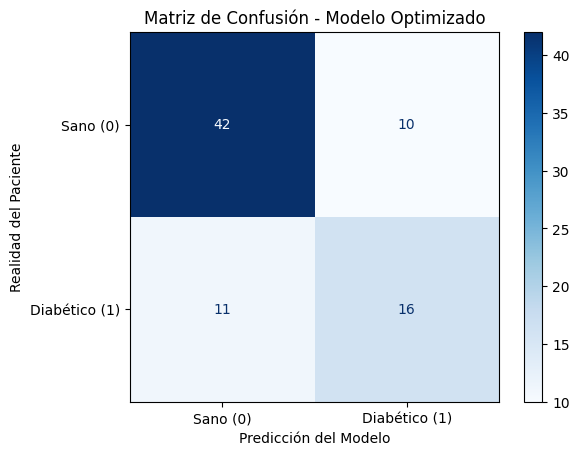

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calculamos la matriz con los resultados de tu modelo optimizado
cm = confusion_matrix(y_test, y_pred_opt)

# 2. La graficamos de forma elegante
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano (0)', 'Diabético (1)'])
disp.plot(cmap='Blues', values_format='d')

plt.title('Matriz de Confusión - Modelo Optimizado')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad del Paciente')
plt.show()

In [136]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Creamos el modelo usando tus mejores hiperparámetros encontrados
# pero añadiendo el balanceo de clases
clf_balanced = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5, 
    min_samples_leaf=5, 
    min_samples_split=20,
    class_weight=None,  # <--- El cambio clave
    random_state=42
)

# 2. Entrenamos y predecimos
clf_balanced.fit(x_train, y_train)
y_pred_balanced = clf_balanced.predict(x_test)

# 3. Mostramos el nuevo informe
print("--- Informe de Clasificación (Modelo Balanceado) ---")
print(classification_report(y_test, y_pred_balanced))

# 4. Comparamos con la matriz de confusión anterior
print("\nNueva Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_balanced))

--- Informe de Clasificación (Modelo Balanceado) ---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80        52
           1       0.62      0.59      0.60        27

    accuracy                           0.73        79
   macro avg       0.70      0.70      0.70        79
weighted avg       0.73      0.73      0.73        79


Nueva Matriz de Confusión:
[[42 10]
 [11 16]]
